# Tutorial Notebook  
## Building & Training Realistic Deep Learning Models with Interactive CNN Design

This notebook is the **next step** after the introductory deep learning frameworks tutorial.

In the previous notebook, you trained a small model on a simple synthetic dataset.
Here, you will move to a **realistic image classification task** and learn how to build, adjust, train, and evaluate a **convolutional neural network (CNN)** in both **TensorFlow/Keras** and **PyTorch**.

---

## What is covered in this notebook?

This notebook focuses on four big ideas:

1. **A realistic model**
   - We move from toy classification to a real image dataset.
   - You will train a CNN rather than a small fully connected network.

2. **Architecture design**
   - You will control important design choices such as:
     - number of convolution blocks,
     - number of filters,
     - kernel size,
     - activation function,
     - dropout,
     - batch normalization,
     - dense layer size.

3. **Interactive experimentation**
   - You can change settings directly in the notebook.
   - You can compare training behavior, validation accuracy, and runtime.

4. **Practical inference**
   - After training, you can upload an image from your own device and see the model's prediction.

---

## What you will build

By the end of this notebook, you will be able to:

- build a configurable CNN in **TensorFlow/Keras**,
- build the same idea in **PyTorch**,
- understand how layers work together in a deeper architecture,
- compare common hyperparameter choices,
- measure training time,
- inspect performance with visualizations,
- and run inference on an image that you upload yourself.

---

## Dataset choice

We use **CIFAR-10**, a classic image classification dataset with 10 categories:

- airplane
- automobile
- bird
- cat
- deer
- dog
- frog
- horse
- ship
- truck

Why CIFAR-10?

- It is much more realistic than a 2D toy dataset.
- It is still small enough to run on a laptop.
- It is a good enough dataset for CNNs.
- Learners can often test the trained model on their own pictures of common objects.

> Important note:
> CIFAR-10 images are very small (`32x32`), so predictions on your own photos may not always be highly accurate.
> That limitation is part of the learning process: real-world inference depends heavily on data quality, resolution, and domain match.

---

## Learning outcomes

By the end of this notebook, you should be able to:

1. explain why CNNs are better suited than plain MLPs for image tasks,
2. describe the role of convolution, pooling, normalization, dropout, and dense layers,
3. build configurable multi-layer architectures in both Keras and PyTorch,
4. explain what major hyperparameters do and how they affect training,
5. compare activation functions, optimizers, and architecture depth,
6. measure runtime and relate it to model complexity,
7. and evaluate a trained model using multiple visual tools.

---

## Suggested workflow

Run the notebook in this order:

1. inspect the data,
2. study the architecture building blocks,
3. choose settings with the widgets,
4. build the model,
5. train it,
6. evaluate it,
7. compare alternative settings,
8. upload your own image and test inference.

The notebook is designed so that you can come back later and change **one thing at a time**.
That is the best way to learn what each design choice really does.


## 1. Official References Used Throughout This Notebook

The tutorial intentionally points to official or high-quality learning resources so you can continue studying each topic in depth.

### TensorFlow / Keras
- TensorFlow tutorials: https://www.tensorflow.org/tutorials
- TensorBoard overview: https://www.tensorflow.org/tensorboard
- TensorBoard in notebooks: https://www.tensorflow.org/tensorboard/tensorboard_in_notebooks
- Keras developer guides: https://keras.io/guides/
- Keras Sequential guide: https://keras.io/guides/sequential_model/
- Keras Functional API guide: https://keras.io/guides/functional_api/
- Keras subclassing guide: https://keras.io/guides/making_new_layers_and_models_via_subclassing/
- Keras callbacks API: https://keras.io/api/callbacks/

### PyTorch
- PyTorch tutorials: https://docs.pytorch.org/tutorials/
- PyTorch Datasets & DataLoaders: https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html
- PyTorch data loading & transforms tutorial: https://docs.pytorch.org/tutorials/beginner/data_loading_tutorial.html
- TorchVision transforms: https://docs.pytorch.org/vision/stable/transforms.html
- PyTorch autograd notes: https://docs.pytorch.org/docs/stable/notes/autograd.html
- PyTorch profiler recipe: https://docs.pytorch.org/tutorials/recipes/recipes/profiler_recipe.html

### Concept-focused reading
- CS231n CNN notes: https://cs231n.github.io/convolutional-networks/
- Batch Normalization paper: https://arxiv.org/abs/1502.03167
- Dropout paper: https://www.cs.toronto.edu/~hinton/absps/JMLRdropout.pdf
- ResNet paper: https://arxiv.org/abs/1512.03385
- Sebastian Ruder on optimization: https://www.ruder.io/optimizing-gradient-descent/

A good habit is to begin with the official documentation, then use videos, tutorials, or forums to reinforce your understanding.


## 2. Environment Setup for This Notebook

If needed, create a clean environment before running this tutorial.

### Option A: `venv`

```bash
python -m venv dl-cnn-env
# Linux / macOS
source dl-cnn-env/bin/activate
# Windows
dl-cnn-env\Scripts\activate
```

### Option B: Conda

```bash
conda create -n dl-cnn-env python=3.11
conda activate dl-cnn-env
```

### Suggested packages

```bash
pip install tensorflow torch torchvision ipywidgets pillow scikit-learn matplotlib pandas
```

> If you only want to run one framework locally, that is okay.
> The notebook still shows both implementations so that you can compare their style and workflow.


In [1]:
# If needed, uncomment and run the next line once.
# %pip install tensorflow torch torchvision ipywidgets pillow scikit-learn matplotlib pandas


## 3. Imports, Reproducibility, and Environment Checks

This notebook supports both TensorFlow/Keras and PyTorch.
You do **not** need both to be installed to read the notebook, but you do need the framework you want to execute.

We also import `ipywidgets` because later sections use widgets for interactive hyperparameter input.


In [2]:
import os
import time
import random
import math
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import display, Markdown, clear_output

try:
    import ipywidgets as widgets
    HAS_WIDGETS = True
except Exception as e:
    HAS_WIDGETS = False
    print("ipywidgets import failed:", e)

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# TensorFlow check
HAS_TF = False
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    tf.random.set_seed(SEED)
    HAS_TF = True
    print("TensorFlow version:", tf.__version__)
    print("TensorFlow GPUs:", tf.config.list_physical_devices("GPU"))
except Exception as e:
    print("TensorFlow not available:", e)

# PyTorch check
HAS_TORCH = False
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
    import torchvision
    from torchvision import transforms
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    HAS_TORCH = True
    print("PyTorch version:", torch.__version__)
    print("TorchVision version:", torchvision.__version__)
    print("PyTorch CUDA available:", torch.cuda.is_available())
except Exception as e:
    print("PyTorch not available:", e)

print("Widgets available:", HAS_WIDGETS)


I0000 00:00:1776417592.856432   51510 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776417592.857271   51510 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776417592.891919   51510 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776417594.105232   51510 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

TensorFlow version: 2.21.0
TensorFlow GPUs: []


E0000 00:00:1776417594.506604   51510 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776417594.517012   51510 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


PyTorch version: 2.11.0+cu130
TorchVision version: 0.26.0+cu130
PyTorch CUDA available: False
Widgets available: True


/home/muditha/Applied-artificial-intelligence/myenv/lib/python3.10/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 302: Error loading CUDA libraries. GPU will not be used. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## 4. Load a More Realistic Dataset: CIFAR-10

CIFAR-10 contains 60,000 small RGB images in 10 classes.
This is still a good dataset, but it is much closer to a real computer vision workflow than a synthetic 2D dataset.

### Why CNNs are a good fit here

A fully connected network would ignore the spatial structure of an image.
A CNN is better because it can:

- detect local patterns such as edges and corners,
- reuse the same filters across the image,
- build increasingly abstract features as depth increases,
- and do so with far fewer parameters than a dense network on raw pixels.


In [3]:
if HAS_TF:
    (X_train_full, y_train_full), (X_test_full, y_test_full) = keras.datasets.cifar10.load_data()
    y_train_full = y_train_full.squeeze()
    y_test_full = y_test_full.squeeze()
elif HAS_TORCH:
    from torchvision.datasets import CIFAR10

    train_ds_raw = CIFAR10(root="./data", train=True, download=True)
    test_ds_raw = CIFAR10(root="./data", train=False, download=True)

    X_train_full = np.array(train_ds_raw.data)
    y_train_full = np.array(train_ds_raw.targets)
    X_test_full = np.array(test_ds_raw.data)
    y_test_full = np.array(test_ds_raw.targets)
else:
    raise RuntimeError(
        "Neither TensorFlow/Keras nor PyTorch/TorchVision is available. "
        "Install at least one framework to load CIFAR-10."
    )

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("Training images:", X_train_full.shape)
print("Training labels:", y_train_full.shape)
print("Test images:", X_test_full.shape)
print("Test labels:", y_test_full.shape)
print("Class names:", class_names)


Training images: (50000, 32, 32, 3)
Training labels: (50000,)
Test images: (10000, 32, 32, 3)
Test labels: (10000,)
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [4]:
# Split a validation set from the original training set
from sklearn.model_selection import train_test_split

X_train_all = X_train_full.astype("float32") / 255.0
X_test_all = X_test_full.astype("float32") / 255.0

X_train_all, X_val_all, y_train_all, y_val_all = train_test_split(
    X_train_all,
    y_train_full,
    test_size=0.15,
    random_state=SEED,
    stratify=y_train_full,
)

print("Train:", X_train_all.shape, y_train_all.shape)
print("Validation:", X_val_all.shape, y_val_all.shape)
print("Test:", X_test_all.shape, y_test_full.shape)


Train: (42500, 32, 32, 3) (42500,)
Validation: (7500, 32, 32, 3) (7500,)
Test: (10000, 32, 32, 3) (10000,)


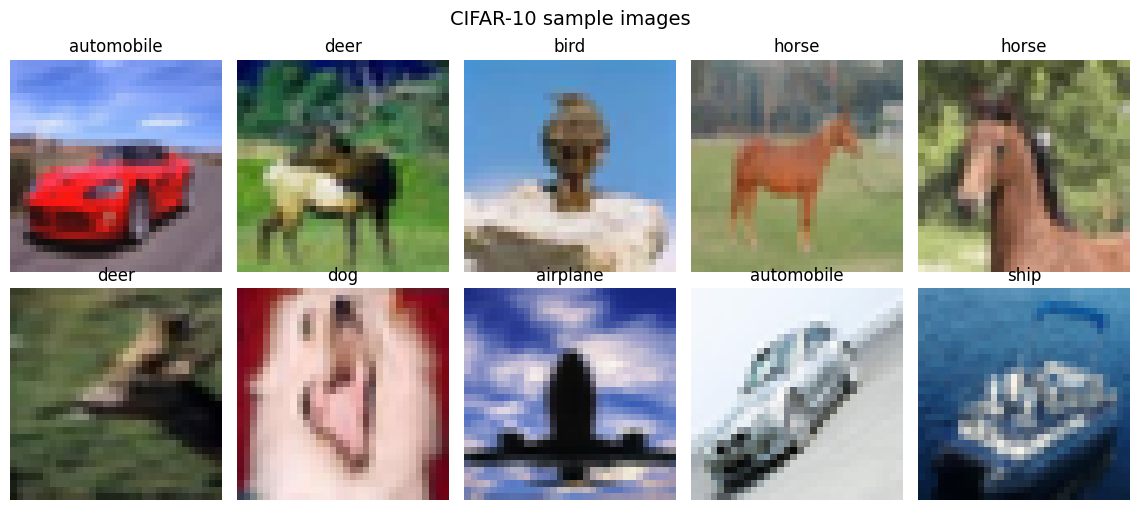

In [5]:
def show_sample_grid(images, labels, class_names, rows=2, cols=5, title="Sample images"):
    plt.figure(figsize=(2.3 * cols, 2.6 * rows))
    for i in range(rows * cols):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

show_sample_grid(X_train_all[:10], y_train_all[:10], class_names, title="CIFAR-10 sample images")


In [6]:
# Class distribution
train_counts = pd.Series(y_train_all).value_counts().sort_index()
val_counts = pd.Series(y_val_all).value_counts().sort_index()
test_counts = pd.Series(y_test_full).value_counts().sort_index()

distribution_df = pd.DataFrame({
    "class": class_names,
    "train_count": train_counts.values,
    "val_count": val_counts.values,
    "test_count": test_counts.values,
})

distribution_df


,class,train_count,val_count,test_count
0,airplane,4250,750,1000
1,automobile,4250,750,1000
2,bird,4250,750,1000
3,cat,4250,750,1000
4,deer,4250,750,1000
5,dog,4250,750,1000
6,frog,4250,750,1000
7,horse,4250,750,1000
8,ship,4250,750,1000
9,truck,4250,750,1000


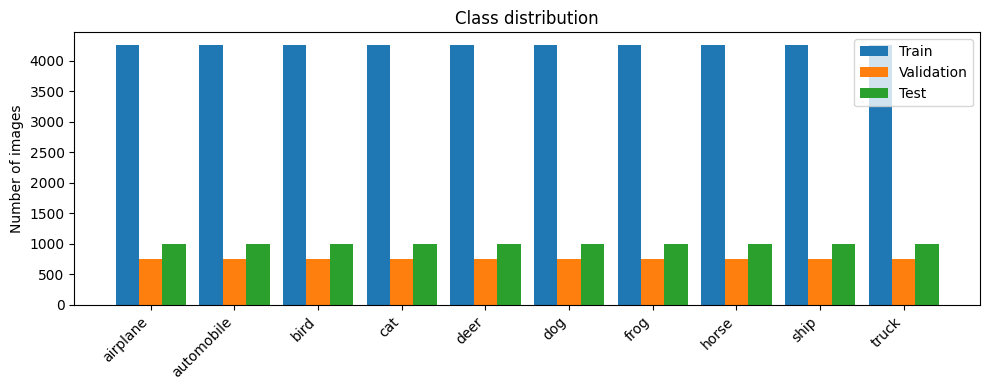

In [7]:
plt.figure(figsize=(10, 4))
x = np.arange(len(class_names))
width = 0.28

plt.bar(x - width, distribution_df["train_count"], width=width, label="Train")
plt.bar(x, distribution_df["val_count"], width=width, label="Validation")
plt.bar(x + width, distribution_df["test_count"], width=width, label="Test")
plt.xticks(x, class_names, rotation=45, ha="right")
plt.ylabel("Number of images")
plt.title("Class distribution")
plt.legend()
plt.tight_layout()
plt.show()


### Keras vs. PyTorch note after data loading

- **TensorFlow/Keras** often feels compact for built-in datasets and quick prototyping.
- **PyTorch** is equally capable, but often emphasizes more explicit dataset and dataloader structure.
- In this notebook, we load CIFAR-10 once and reuse the arrays for both frameworks so you can focus on the **architecture and training differences** rather than on duplicate data setup code.


## 5. Architecture Building Blocks: What Each Layer Does

Before training a deeper model, it is important to understand what the major layers are doing.

### 5.1 Convolution layer (`Conv2D`)
A convolution layer applies small filters across the image.

What it does:
- learns local patterns such as edges, corners, or textures,
- shares weights across locations,
- preserves spatial structure much better than a dense layer on raw pixels.

Important parameters:
- **filters**: how many learned feature detectors the layer has
- **kernel size**: the size of the sliding window (for example `3x3` or `5x5`)
- **stride**: how far the filter moves each step
- **padding**: whether to preserve spatial size at the borders

Typical effects:
- more filters -> more representational capacity, more parameters, more compute
- larger kernels -> larger receptive field, but more compute and sometimes less precision for small details

### 5.2 Activation function
The activation introduces nonlinearity.

Common choices:
- **ReLU**: simple, fast, and very common
- **LeakyReLU**: similar to ReLU but keeps a small negative slope
- **GELU**: smoother activation used often in modern architectures

Typical effects:
- ReLU is a strong default for CNNs
- LeakyReLU can reduce “dead neuron” behavior
- GELU can work very well, but is slightly heavier computationally

### 5.3 Pooling layer
Pooling reduces spatial resolution.

Common choices:
- **MaxPooling**: keeps the strongest local response
- **AveragePooling**: keeps the local average

Typical effects:
- pooling reduces memory and computation,
- adds some translation robustness,
- but too much pooling can destroy useful detail.

### 5.4 Batch normalization
Batch normalization normalizes activations during training.

Why it helps:
- stabilizes optimization,
- often allows faster training,
- can make deeper models easier to train.

Trade-off:
- adds extra parameters and computation,
- may interact with batch size and training setup.

### 5.5 Dropout
Dropout randomly turns off a fraction of activations during training.

Why it helps:
- regularizes the model,
- reduces overfitting,
- encourages more robust internal representations.

Trade-off:
- too much dropout can make learning harder or slower.

### 5.6 Dense layer
Dense layers are usually placed near the end of a CNN.
They combine the extracted features into class predictions.

Typical effects:
- larger dense layers increase capacity,
- but also increase parameter count and overfitting risk.

### 5.7 Softmax output
For multiclass classification, the final layer usually has:
- one output unit per class,
- followed by **softmax**,
- producing a probability distribution across classes.

Further reading:
- CS231n CNN notes: https://cs231n.github.io/convolutional-networks/
- Keras layers API: https://keras.io/api/layers/
- PyTorch modules: https://docs.pytorch.org/docs/stable/nn.html


## 6. Hyperparameters You Will Control Interactively

This notebook lets you change several design and training choices.

### Architecture parameters
- **number of convolution blocks**
- **base number of filters**
- **kernel size**
- **activation**
- **use batch normalization**
- **dropout rate**
- **dense layer size**

### Training parameters
- **framework**
- **optimizer**
- **learning rate**
- **batch size**
- **epochs**
- **whether to use data augmentation**
- **subset size** (to trade off realism and runtime)

### What “more layers” means in practice

A deeper network can learn richer and more hierarchical features.
However, increasing depth also affects:

- runtime,
- memory use,
- optimization stability,
- overfitting risk,
- and the number of parameters.

That is why we will always look at:
- **accuracy**
- **loss curves**
- **confusion matrix**
- **per-class behavior**
- **training time**

instead of treating “deeper” as automatically “better”.


In [8]:
if HAS_WIDGETS:
    framework_widget = widgets.Dropdown(
        options=["TensorFlow/Keras", "PyTorch"],
        value="TensorFlow/Keras" if HAS_TF else "PyTorch",
        description="Framework:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="260px")
    )

    subset_widget = widgets.Dropdown(
        options=[3000, 5000, 10000, 15000, "full"],
        value=10000,
        description="Train subset:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="260px")
    )

    conv_blocks_widget = widgets.IntSlider(
        value=3, min=2, max=4, step=1, description="Conv blocks:",
        style={"description_width": "initial"}, continuous_update=False
    )

    base_filters_widget = widgets.Dropdown(
        options=[16, 32, 48, 64],
        value=32,
        description="Base filters:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="260px")
    )

    kernel_widget = widgets.Dropdown(
        options=[3, 5],
        value=3,
        description="Kernel size:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="260px")
    )

    activation_widget = widgets.Dropdown(
        options=["relu", "leaky_relu", "gelu"],
        value="relu",
        description="Activation:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="260px")
    )

    batch_norm_widget = widgets.Checkbox(
        value=True, description="Use batch normalization"
    )

    dropout_widget = widgets.FloatSlider(
        value=0.25, min=0.0, max=0.6, step=0.05, description="Dropout:",
        style={"description_width": "initial"}, continuous_update=False
    )

    dense_widget = widgets.Dropdown(
        options=[64, 128, 256],
        value=128,
        description="Dense units:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="260px")
    )

    optimizer_widget = widgets.Dropdown(
        options=["adam", "sgd", "rmsprop"],
        value="adam",
        description="Optimizer:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="260px")
    )

    lr_widget = widgets.Dropdown(
        options=[1e-4, 3e-4, 1e-3, 3e-3, 1e-2],
        value=1e-3,
        description="Learning rate:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="260px")
    )

    batch_size_widget = widgets.Dropdown(
        options=[32, 64, 128],
        value=64,
        description="Batch size:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="260px")
    )

    epochs_widget = widgets.IntSlider(
        value=8, min=3, max=20, step=1, description="Epochs:",
        style={"description_width": "initial"}, continuous_update=False
    )

    augment_widget = widgets.Checkbox(
        value=True, description="Use augmentation"
    )

    show_controls = widgets.VBox([
        widgets.HTML("<h4>Interactive model and training controls</h4>"),
        widgets.HBox([framework_widget, subset_widget]),
        widgets.HBox([conv_blocks_widget, base_filters_widget, kernel_widget]),
        widgets.HBox([activation_widget, dense_widget]),
        widgets.HBox([optimizer_widget, lr_widget, batch_size_widget]),
        widgets.HBox([epochs_widget, dropout_widget]),
        widgets.HBox([batch_norm_widget, augment_widget]),
    ])

    display(show_controls)
else:
    print("ipywidgets is not available. Install it to use the interactive controls.")


In [9]:
@dataclass
class Config:
    framework: str = "TensorFlow/Keras"
    train_subset: int | str = 10000
    conv_blocks: int = 3
    base_filters: int = 32
    kernel_size: int = 3
    activation: str = "relu"
    use_batch_norm: bool = True
    dropout_rate: float = 0.25
    dense_units: int = 128
    optimizer_name: str = "adam"
    learning_rate: float = 1e-3
    batch_size: int = 64
    epochs: int = 8
    use_augmentation: bool = True

def get_current_config():
    if HAS_WIDGETS:
        return Config(
            framework=framework_widget.value,
            train_subset=subset_widget.value,
            conv_blocks=conv_blocks_widget.value,
            base_filters=base_filters_widget.value,
            kernel_size=kernel_widget.value,
            activation=activation_widget.value,
            use_batch_norm=batch_norm_widget.value,
            dropout_rate=dropout_widget.value,
            dense_units=dense_widget.value,
            optimizer_name=optimizer_widget.value,
            learning_rate=float(lr_widget.value),
            batch_size=batch_size_widget.value,
            epochs=epochs_widget.value,
            use_augmentation=augment_widget.value,
        )
    return Config()

current_config = get_current_config()
pd.Series(asdict(current_config))


framework           TensorFlow/Keras
train_subset                   10000
conv_blocks                        3
base_filters                      32
kernel_size                        3
activation                      relu
use_batch_norm                  True
dropout_rate                    0.25
dense_units                      128
optimizer_name                  adam
learning_rate                  0.001
batch_size                        64
epochs                             8
use_augmentation                True
dtype: object

### Keras vs. PyTorch note after the interactive controls

- In both frameworks, the **conceptual hyperparameters are the same**.
- What changes is the **coding style**:
  - Keras often exposes them through model constructors and `compile()` settings.
  - PyTorch often exposes them through explicit modules, optimizer objects, and manual loops.
- The learner benefit is that you can see that the **same machine learning idea** can appear in two syntactically different, but conceptually equivalent, implementations.


## 7. Build the Same CNN in Two Frameworks

We will now create model-builder functions for:

- **TensorFlow/Keras**
- **PyTorch**

The goal is not to create a huge state-of-the-art model.
The goal is to create a **clean, configurable CNN** that is deep enough to be realistic and simple enough to understand.

### Architecture pattern used here

Each convolution block follows this rough pattern:

`Conv -> Activation -> (BatchNorm optional) -> Pool`

and then near the end:

`Flatten -> Dense -> Dropout -> Dense(softmax/logits)`

This is a very common learning-friendly CNN pattern.


In [10]:
def apply_tf_activation(x, activation_name):
    if activation_name == "relu":
        return layers.Activation("relu")(x)
    if activation_name == "gelu":
        return layers.Activation(tf.nn.gelu)(x)
    if activation_name == "leaky_relu":
        return layers.LeakyReLU()(x)
    raise ValueError(f"Unsupported activation: {activation_name}")

def build_keras_cnn(config: Config):
    if not HAS_TF:
        raise RuntimeError("TensorFlow/Keras is not installed.")

    inputs = keras.Input(shape=(32, 32, 3))
    x = inputs

    if config.use_augmentation:
        aug = keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomTranslation(0.1, 0.1),
            layers.RandomZoom(0.1, 0.1),
        ], name="augmentation")
        x = aug(x)

    filters = config.base_filters
    for block_idx in range(config.conv_blocks):
        x = layers.Conv2D(filters, (config.kernel_size, config.kernel_size), padding="same")(x)
        x = apply_tf_activation(x, config.activation)
        if config.use_batch_norm:
            x = layers.BatchNormalization()(x)

        x = layers.Conv2D(filters, (config.kernel_size, config.kernel_size), padding="same")(x)
        x = apply_tf_activation(x, config.activation)
        if config.use_batch_norm:
            x = layers.BatchNormalization()(x)

        x = layers.MaxPooling2D(pool_size=(2, 2))(x)
        if config.dropout_rate > 0:
            x = layers.Dropout(config.dropout_rate)(x)
        filters *= 2

    x = layers.Flatten()(x)
    x = layers.Dense(config.dense_units)(x)
    x = apply_tf_activation(x, config.activation)
    if config.dropout_rate > 0:
        x = layers.Dropout(config.dropout_rate)(x)
    outputs = layers.Dense(10, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="interactive_cnn")

    if config.optimizer_name == "adam":
        optimizer = keras.optimizers.Adam(learning_rate=config.learning_rate)
    elif config.optimizer_name == "sgd":
        optimizer = keras.optimizers.SGD(learning_rate=config.learning_rate, momentum=0.9)
    elif config.optimizer_name == "rmsprop":
        optimizer = keras.optimizers.RMSprop(learning_rate=config.learning_rate)
    else:
        raise ValueError(f"Unsupported optimizer: {config.optimizer_name}")

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


In [11]:
def make_torch_activation(activation_name: str):
    if activation_name == "relu":
        return nn.ReLU()
    if activation_name == "gelu":
        return nn.GELU()
    if activation_name == "leaky_relu":
        return nn.LeakyReLU(negative_slope=0.01)
    raise ValueError(f"Unsupported activation: {activation_name}")

class TorchCNN(nn.Module):
    def __init__(self, config: Config):
        super().__init__()
        self.config = config

        blocks = []
        in_channels = 3
        filters = config.base_filters

        for _ in range(config.conv_blocks):
            block_layers = [
                nn.Conv2d(in_channels, filters, kernel_size=config.kernel_size, padding=config.kernel_size // 2),
                make_torch_activation(config.activation),
            ]
            if config.use_batch_norm:
                block_layers.append(nn.BatchNorm2d(filters))

            block_layers.extend([
                nn.Conv2d(filters, filters, kernel_size=config.kernel_size, padding=config.kernel_size // 2),
                make_torch_activation(config.activation),
            ])
            if config.use_batch_norm:
                block_layers.append(nn.BatchNorm2d(filters))

            block_layers.append(nn.MaxPool2d(kernel_size=2))
            if config.dropout_rate > 0:
                block_layers.append(nn.Dropout(config.dropout_rate))

            blocks.extend(block_layers)
            in_channels = filters
            filters *= 2

        self.features = nn.Sequential(*blocks)

        # infer flattened size with a dummy forward pass
        with torch.no_grad():
            dummy = torch.zeros(1, 3, 32, 32)
            flat_dim = self.features(dummy).reshape(1, -1).shape[1]

        classifier_layers = [
            nn.Flatten(),
            nn.Linear(flat_dim, config.dense_units),
            make_torch_activation(config.activation),
        ]
        if config.dropout_rate > 0:
            classifier_layers.append(nn.Dropout(config.dropout_rate))
        classifier_layers.append(nn.Linear(config.dense_units, 10))

        self.classifier = nn.Sequential(*classifier_layers)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def count_torch_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [12]:
def summarize_current_models(config=None):
    if config is None:
        config = get_current_config()

    print("Current configuration:")
    print(pd.Series(asdict(config)).to_string())
    print("\n" + "=" * 70)

    if HAS_TF:
        print("TensorFlow/Keras model")
        keras_model = build_keras_cnn(config)
        keras_model.summary()
        print("=" * 70)

    if HAS_TORCH:
        print("PyTorch model")
        torch_model = TorchCNN(config)
        print(torch_model)
        print(f"Trainable parameters: {count_torch_parameters(torch_model):,}")

summarize_current_models()


Current configuration:
framework           TensorFlow/Keras
train_subset                   10000
conv_blocks                        3
base_filters                      32
kernel_size                        3
activation                      relu
use_batch_norm                  True
dropout_rate                    0.25
dense_units                      128
optimizer_name                  adam
learning_rate                  0.001
batch_size                        64
epochs                             8
use_augmentation                True

TensorFlow/Keras model


Model: "interactive_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 552,362 (2.11 MB)

 Trainable params: 551,466 (2.10 MB)

 Non-trainable params: 896 (3.50 KB)

PyTorch model
TorchCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU()
    (13): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout(

### Keras vs. PyTorch note after model construction

- **Keras** makes full-model construction feel like assembling a graph of layers, then calling `compile()`.
- **PyTorch** makes the architecture feel more like standard Python classes, with the `forward()` method describing the data flow explicitly.
- Both are building the same conceptual object: a function that maps an image to class probabilities or logits.


## 8. Sequential, Functional, and Custom Modules: When to Use Each

### Keras `Sequential`
Best when:
- the model is a simple stack,
- one layer flows directly into the next,
- there are no branches or skip connections.

### Keras Functional API
Best when:
- the network is not purely linear,
- you want skip connections,
- you want shared layers or multiple inputs/outputs.

### PyTorch `nn.Module`
PyTorch commonly uses `nn.Module` from the beginning.
This naturally supports:
- custom logic,
- conditionals,
- reusable blocks,
- branching architectures,
- residual connections.

### Simple residual / skip connection idea

Skip connections help deeper networks by allowing information and gradients to flow more easily across layers.

Further reading:
- Keras Functional API: https://keras.io/guides/functional_api/
- Keras subclassing: https://keras.io/guides/making_new_layers_and_models_via_subclassing/
- ResNet paper: https://arxiv.org/abs/1512.03385


In [13]:
# Optional: a tiny residual block example in Keras
if HAS_TF:
    inp = keras.Input(shape=(32, 32, 16))
    x = layers.Conv2D(16, 3, padding="same")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(16, 3, padding="same")(x)
    x = layers.Add()([x, inp])
    out = layers.Activation("relu")(x)
    residual_demo_keras = keras.Model(inp, out, name="keras_residual_demo")
    residual_demo_keras.summary()


Model: "keras_residual_demo"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 32, 32,    │          0 │ -                 │
│ (InputLayer)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │      2,320 │ input_layer_2[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │      2,320 │ activation_7[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ conv2d_7[0][0],   │
│                     │ 16)               │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 32, 32,    │          0 │ add[0][0]         │
│ (Activation)        │ 16)               │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,704 (18.38 KB)

 Trainable params: 4,672 (18.25 KB)

 Non-trainable params: 32 (128.00 B)

In [14]:
# Optional: a tiny residual block example in PyTorch
if HAS_TORCH:
    class ResidualBlock(nn.Module):
        def __init__(self, channels=16):
            super().__init__()
            self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
            self.bn1 = nn.BatchNorm2d(channels)
            self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

        def forward(self, x):
            identity = x
            out = self.conv1(x)
            out = self.bn1(out)
            out = F.relu(out)
            out = self.conv2(out)
            out = out + identity
            return F.relu(out)

    residual_demo_torch = ResidualBlock(channels=16)
    print(residual_demo_torch)


ResidualBlock(
  (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)


## 9. Data Pipelines for Training

To compare frameworks fairly, we use the same dataset split and a very similar preprocessing strategy.

### What the pipeline should do

- keep images and labels aligned,
- batch the data,
- optionally augment training images,
- feed tensors in the format expected by each framework.

### Important shape difference

- **TensorFlow/Keras image format**: `(batch, height, width, channels)`
- **PyTorch image format**: `(batch, channels, height, width)`

This is one of the first practical differences learners notice.


In [15]:
def get_subset_data(train_subset):
    if train_subset == "full":
        return X_train_all, y_train_all, X_val_all, y_val_all, X_test_all, y_test_full

    n = int(train_subset)
    X_train = X_train_all[:n]
    y_train = y_train_all[:n]

    val_n = min(max(n // 5, 1000), len(X_val_all))
    test_n = min(max(n // 5, 1000), len(X_test_all))

    X_val = X_val_all[:val_n]
    y_val = y_val_all[:val_n]
    X_test = X_test_all[:test_n]
    y_test = y_test_full[:test_n]

    return X_train, y_train, X_val, y_val, X_test, y_test

X_train, y_train, X_val, y_val, X_test, y_test = get_subset_data(get_current_config().train_subset)
print("Subset train:", X_train.shape)
print("Subset validation:", X_val.shape)
print("Subset test:", X_test.shape)


Subset train: (10000, 32, 32, 3)
Subset validation: (2000, 32, 32, 3)
Subset test: (2000, 32, 32, 3)


In [16]:
def make_tf_datasets(config: Config):
    X_train, y_train, X_val, y_val, X_test, y_test = get_subset_data(config.train_subset)

    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
    train_ds = train_ds.shuffle(min(len(X_train), 5000), seed=SEED).batch(config.batch_size).prefetch(tf.data.AUTOTUNE)

    val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(config.batch_size).prefetch(tf.data.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(config.batch_size).prefetch(tf.data.AUTOTUNE)

    return train_ds, val_ds, test_ds, (X_train, y_train, X_val, y_val, X_test, y_test)

class NumpyCIFAR10Dataset(Dataset):
    def __init__(self, images, labels, augment=False):
        self.images = images
        self.labels = labels
        self.augment = augment

        aug_list = []
        if augment:
            aug_list.extend([
                transforms.ToPILImage(),
                transforms.RandomHorizontalFlip(),
                transforms.RandomCrop(32, padding=4),
                transforms.ToTensor(),
            ])
        else:
            aug_list.extend([
                transforms.ToPILImage(),
                transforms.ToTensor(),
            ])
        self.transform = transforms.Compose(aug_list)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = (self.images[idx] * 255).astype(np.uint8)
        label = int(self.labels[idx])
        tensor = self.transform(image)  # C,H,W in [0,1]
        return tensor, label

def make_torch_dataloaders(config: Config):
    if not HAS_TORCH:
        raise RuntimeError("PyTorch is not installed.")

    X_train, y_train, X_val, y_val, X_test, y_test = get_subset_data(config.train_subset)

    train_ds = NumpyCIFAR10Dataset(X_train, y_train, augment=config.use_augmentation)
    val_ds = NumpyCIFAR10Dataset(X_val, y_val, augment=False)
    test_ds = NumpyCIFAR10Dataset(X_test, y_test, augment=False)

    train_loader = DataLoader(train_ds, batch_size=config.batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=config.batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=config.batch_size, shuffle=False)

    return train_loader, val_loader, test_loader, (X_train, y_train, X_val, y_val, X_test, y_test)


## 10. Training Utilities and Runtime Measurement

We now create training helpers for both frameworks.

### What we measure

For each training run we record:

- training loss
- training accuracy
- validation loss
- validation accuracy
- epoch time
- total training time

This matters because a “better” model is not only about accuracy.
It is also about:

- efficiency,
- stability,
- and whether the performance gain is worth the extra compute.


In [17]:
if HAS_TF:
    class TimeHistory(keras.callbacks.Callback):
        def on_train_begin(self, logs=None):
            self.epoch_times = []
            self.train_start = time.perf_counter()

        def on_epoch_begin(self, epoch, logs=None):
            self.epoch_start = time.perf_counter()

        def on_epoch_end(self, epoch, logs=None):
            self.epoch_times.append(time.perf_counter() - self.epoch_start)

        def on_train_end(self, logs=None):
            self.total_time = time.perf_counter() - self.train_start


In [18]:
def train_keras_model(config: Config):
    if not HAS_TF:
        raise RuntimeError("TensorFlow/Keras is not installed.")

    train_ds, val_ds, test_ds, arrays = make_tf_datasets(config)
    model = build_keras_cnn(config)

    time_callback = TimeHistory()
    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
    )

    history_obj = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=config.epochs,
        verbose=1,
        callbacks=[time_callback, early_stopping],
    )

    test_loss, test_acc = model.evaluate(test_ds, verbose=0)

    history = {
        "loss": [float(x) for x in history_obj.history.get("loss", [])],
        "accuracy": [float(x) for x in history_obj.history.get("accuracy", [])],
        "val_loss": [float(x) for x in history_obj.history.get("val_loss", [])],
        "val_accuracy": [float(x) for x in history_obj.history.get("val_accuracy", [])],
    }

    result = {
        "framework": "TensorFlow/Keras",
        "model": model,
        "history": history,
        "epoch_times": [float(x) for x in getattr(time_callback, "epoch_times", [])],
        "total_time": float(getattr(time_callback, "total_time", 0.0)),
        "test_loss": float(test_loss),
        "test_accuracy": float(test_acc),
        "device": "GPU" if tf.config.list_physical_devices("GPU") else "CPU",
        "data_arrays": arrays,
    }
    return result


In [19]:
def get_torch_optimizer(model, config: Config):
    if config.optimizer_name == "adam":
        return torch.optim.Adam(model.parameters(), lr=config.learning_rate)
    if config.optimizer_name == "sgd":
        return torch.optim.SGD(model.parameters(), lr=config.learning_rate, momentum=0.9)
    if config.optimizer_name == "rmsprop":
        return torch.optim.RMSprop(model.parameters(), lr=config.learning_rate)
    raise ValueError(f"Unsupported optimizer: {config.optimizer_name}")

def evaluate_torch_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            running_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)

    return running_loss / total, correct / total

def train_torch_model(config: Config):
    if not HAS_TORCH:
        raise RuntimeError("PyTorch is not installed.")

    train_loader, val_loader, test_loader, arrays = make_torch_dataloaders(config)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = TorchCNN(config).to(device)
    optimizer = get_torch_optimizer(model, config)
    criterion = nn.CrossEntropyLoss()

    history = {
        "loss": [],
        "accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
    }
    epoch_times = []

    best_state = None
    best_val_loss = float("inf")
    patience = 3
    epochs_without_improvement = 0

    total_start = time.perf_counter()

    for epoch in range(config.epochs):
        epoch_start = time.perf_counter()
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)

        train_loss = running_loss / total
        train_acc = correct / total
        val_loss, val_acc = evaluate_torch_model(model, val_loader, criterion, device)

        history["loss"].append(train_loss)
        history["accuracy"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)

        epoch_time = time.perf_counter() - epoch_start
        epoch_times.append(epoch_time)

        print(
            f"Epoch {epoch + 1:02d}/{config.epochs} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | "
            f"time={epoch_time:.2f}s"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print("Early stopping triggered.")
                break

    total_time = time.perf_counter() - total_start

    if best_state is not None:
        model.load_state_dict(best_state)

    test_loss, test_acc = evaluate_torch_model(model, test_loader, criterion, device)

    result = {
        "framework": "PyTorch",
        "model": model,
        "history": history,
        "epoch_times": epoch_times,
        "total_time": total_time,
        "test_loss": float(test_loss),
        "test_accuracy": float(test_acc),
        "device": str(device),
        "data_arrays": arrays,
    }
    return result


## 11. Train the Selected Model

This cell reads your current widget values and trains the selected framework.

### Practical suggestion
Start with:

- `train subset = 5000 or 10000`
- `conv blocks = 3`
- `base filters = 32`
- `activation = relu`
- `optimizer = adam`
- `epochs = 6 to 8`

Then change only **one parameter at a time**.


In [20]:
# Global state used later for evaluation and uploaded-image inference
TRAINED_RESULT = None

config = get_current_config()
print("Training with configuration:")
display(pd.Series(asdict(config)))

if config.framework == "TensorFlow/Keras":
    if not HAS_TF:
        raise RuntimeError("TensorFlow/Keras is not installed.")
    TRAINED_RESULT = train_keras_model(config)
else:
    if not HAS_TORCH:
        raise RuntimeError("PyTorch is not installed.")
    TRAINED_RESULT = train_torch_model(config)

print("\nTraining finished.")
print("Framework:", TRAINED_RESULT["framework"])
print("Total training time (s):", round(TRAINED_RESULT["total_time"], 2))
print("Test accuracy:", round(TRAINED_RESULT["test_accuracy"], 4))


Training with configuration:


framework           TensorFlow/Keras
train_subset                   10000
conv_blocks                        3
base_filters                      32
kernel_size                        3
activation                      relu
use_batch_norm                  True
dropout_rate                    0.25
dense_units                      128
optimizer_name                  adam
learning_rate                  0.001
batch_size                        64
epochs                             8
use_augmentation                True
dtype: object

Epoch 1/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 94ms/step - accuracy: 0.2860 - loss: 2.0258 - val_accuracy: 0.1000 - val_loss: 3.2732
Epoch 2/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 99ms/step - accuracy: 0.3851 - loss: 1.6858 - val_accuracy: 0.1895 - val_loss: 3.1024
Epoch 3/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 102ms/step - accuracy: 0.4361 - loss: 1.5750 - val_accuracy: 0.3470 - val_loss: 1.7939
Epoch 4/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 104ms/step - accuracy: 0.4602 - loss: 1.4889 - val_accuracy: 0.5130 - val_loss: 1.3177
Epoch 5/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 130ms/step - accuracy: 0.4935 - loss: 1.4053 - val_accuracy: 0.4725 - val_loss: 1.5456
Epoch 6/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 158ms/step - accuracy: 0.5134 - loss: 1.3482 - val_accuracy: 0.4730 - val_loss: 1.5508
Epoch 7/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 157ms/step - accuracy: 0.5365 - loss: 1.2903 - val_accuracy: 0.5440 - val_loss: 1.3098
Epoch 8/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 151ms/step - accuracy: 0.5464 - loss: 1.2562 - va

### Keras vs. PyTorch note after training

- **Keras** gives you a compact high-level training path with `model.fit()`, callbacks, and history tracking built in.
- **PyTorch** makes each training step explicit: forward pass, loss computation, backward pass, optimizer update.
- Many learners find Keras faster for first experiments, while PyTorch makes the mechanics of optimization easier to see directly.


## 12. Plot Training Curves and Runtime

A model can seem “good” at first glance, but curves often reveal deeper issues:

- overfitting,
- underfitting,
- unstable optimization,
- or unnecessarily slow training.


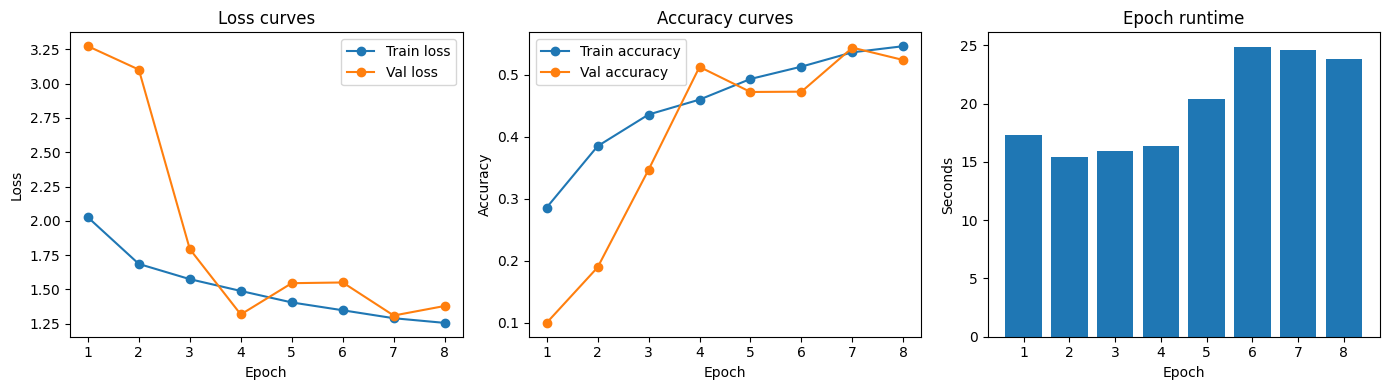

In [21]:
def plot_history_and_time(result):
    history = result["history"]
    epochs = range(1, len(history["loss"]) + 1)

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["loss"], marker="o", label="Train loss")
    plt.plot(epochs, history["val_loss"], marker="o", label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss curves")
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["accuracy"], marker="o", label="Train accuracy")
    plt.plot(epochs, history["val_accuracy"], marker="o", label="Val accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy curves")
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.bar(list(epochs), result["epoch_times"])
    plt.xlabel("Epoch")
    plt.ylabel("Seconds")
    plt.title("Epoch runtime")

    plt.tight_layout()
    plt.show()

if TRAINED_RESULT is not None:
    plot_history_and_time(TRAINED_RESULT)


In [22]:
if TRAINED_RESULT is not None:
    print("Average epoch time (s):", round(float(np.mean(TRAINED_RESULT["epoch_times"])), 2))
    print("Total training time (s):", round(TRAINED_RESULT["total_time"], 2))
    print("Test loss:", round(TRAINED_RESULT["test_loss"], 4))
    print("Test accuracy:", round(TRAINED_RESULT["test_accuracy"], 4))


Average epoch time (s): 19.84
Total training time (s): 158.79
Test loss: 1.2337
Test accuracy: 0.566


### How to read these results

- If training accuracy rises but validation accuracy stalls or falls, the model may be **overfitting**.
- If both training and validation remain poor, the model may be **too weak**, **too shallow**, or using poor optimization settings.
- If performance improves only slightly while epoch time grows a lot, the extra complexity may not be worthwhile.

Useful follow-up reading:
- TensorBoard: https://www.tensorflow.org/tensorboard
- PyTorch profiler: https://docs.pytorch.org/tutorials/recipes/recipes/profiler_recipe.html


## 13. Evaluate the Model More Thoroughly

Accuracy alone is not enough.
We also want to inspect:

- confusion matrix,
- per-class accuracy,
- correct vs. incorrect predictions,
- and example predictions.


In [23]:
from sklearn.metrics import confusion_matrix, classification_report

def get_predictions(result):
    X_train, y_train, X_val, y_val, X_test, y_test = result["data_arrays"]

    if result["framework"] == "TensorFlow/Keras":
        probs = result["model"].predict(X_test, verbose=0)
        preds = probs.argmax(axis=1)
    else:
        model = result["model"]
        device = torch.device(result.get("device", "cpu"))
        model.eval()
        X_tensor = torch.tensor(np.transpose(X_test, (0, 3, 1, 2)), dtype=torch.float32).to(device)
        with torch.no_grad():
            logits = model(X_tensor)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = probs.argmax(axis=1)

    return X_test, y_test, probs, preds

if TRAINED_RESULT is not None:
    X_eval, y_eval, prob_eval, pred_eval = get_predictions(TRAINED_RESULT)
    cm = confusion_matrix(y_eval, pred_eval)
    print(classification_report(y_eval, pred_eval, target_names=class_names))


              precision    recall  f1-score   support

    airplane       0.63      0.58      0.60       196
  automobile       0.57      0.91      0.70       198
        bird       0.53      0.25      0.34       195
         cat       0.37      0.29      0.32       199
        deer       0.54      0.47      0.50       198
         dog       0.52      0.32      0.40       185
        frog       0.46      0.83      0.59       216
       horse       0.74      0.62      0.67       193
        ship       0.81      0.68      0.74       217
       truck       0.56      0.66      0.61       203

    accuracy                           0.57      2000
   macro avg       0.57      0.56      0.55      2000
weighted avg       0.57      0.57      0.55      2000



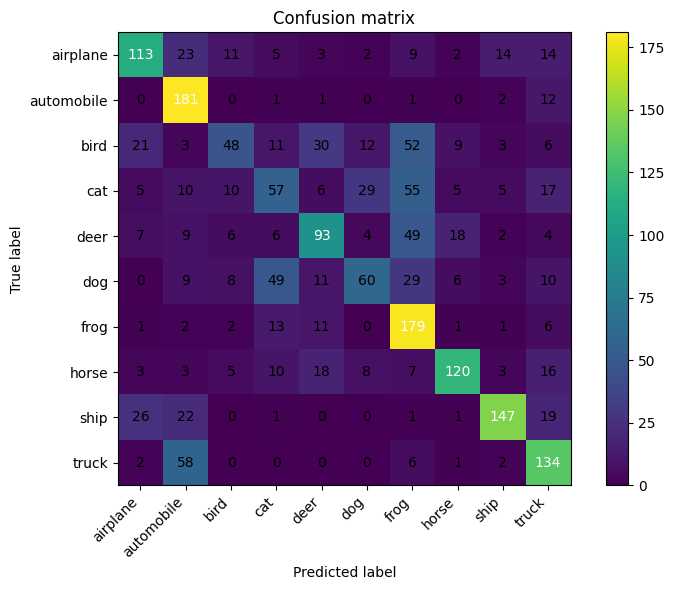

In [24]:
def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion matrix")
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)

    thresh = cm.max() / 2.0 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], "d"),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

if TRAINED_RESULT is not None:
    plot_confusion_matrix(cm, class_names)


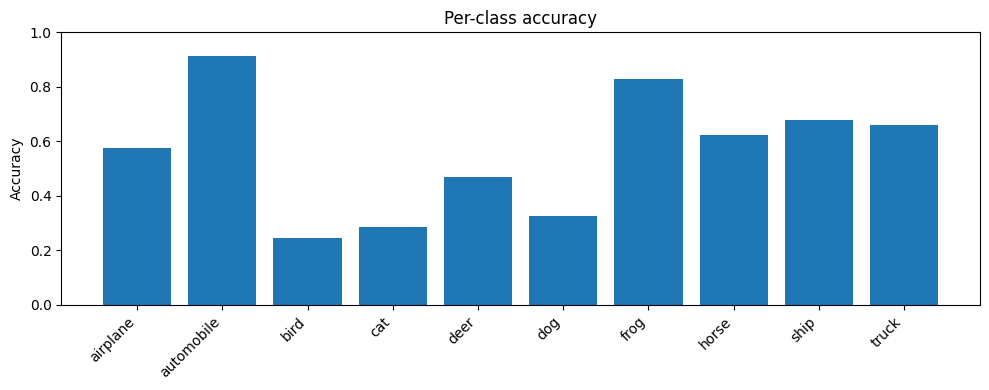

In [25]:
def plot_per_class_accuracy(cm, class_names):
    per_class_acc = cm.diagonal() / np.maximum(cm.sum(axis=1), 1)
    plt.figure(figsize=(10, 4))
    plt.bar(class_names, per_class_acc)
    plt.ylim(0, 1)
    plt.ylabel("Accuracy")
    plt.title("Per-class accuracy")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    return per_class_acc

if TRAINED_RESULT is not None:
    per_class_acc = plot_per_class_accuracy(cm, class_names)
    pd.DataFrame({"class": class_names, "accuracy": per_class_acc}).sort_values("accuracy", ascending=False)


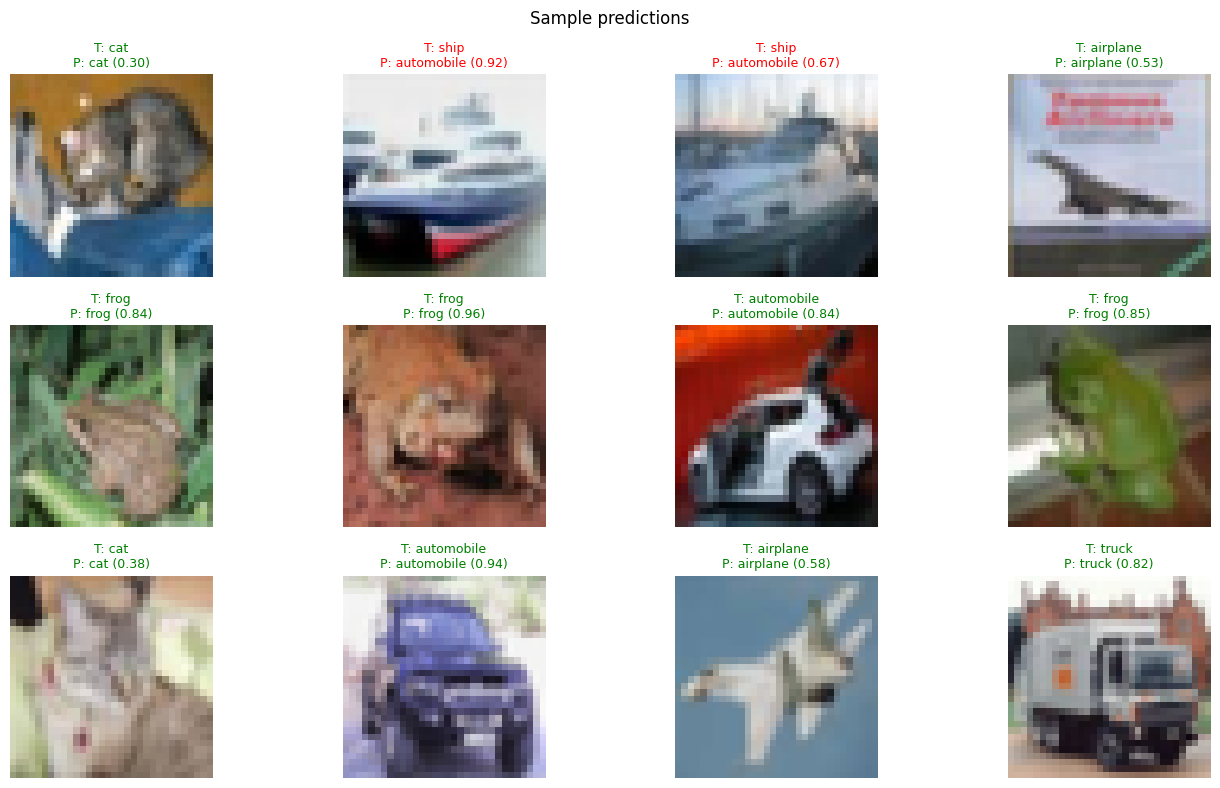

In [26]:
def show_prediction_grid(images, y_true, y_pred, y_prob, class_names, title, n=12):
    plt.figure(figsize=(14, 8))
    idxs = np.arange(min(n, len(images)))
    for i, idx in enumerate(idxs, start=1):
        plt.subplot(3, 4, i)
        plt.imshow(images[idx])
        true_label = class_names[int(y_true[idx])]
        pred_label = class_names[int(y_pred[idx])]
        confidence = float(np.max(y_prob[idx]))
        color = "green" if y_true[idx] == y_pred[idx] else "red"
        plt.title(f"T: {true_label}\nP: {pred_label} ({confidence:.2f})", color=color, fontsize=9)
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

if TRAINED_RESULT is not None:
    show_prediction_grid(X_eval[:12], y_eval[:12], pred_eval[:12], prob_eval[:12], class_names, title="Sample predictions")


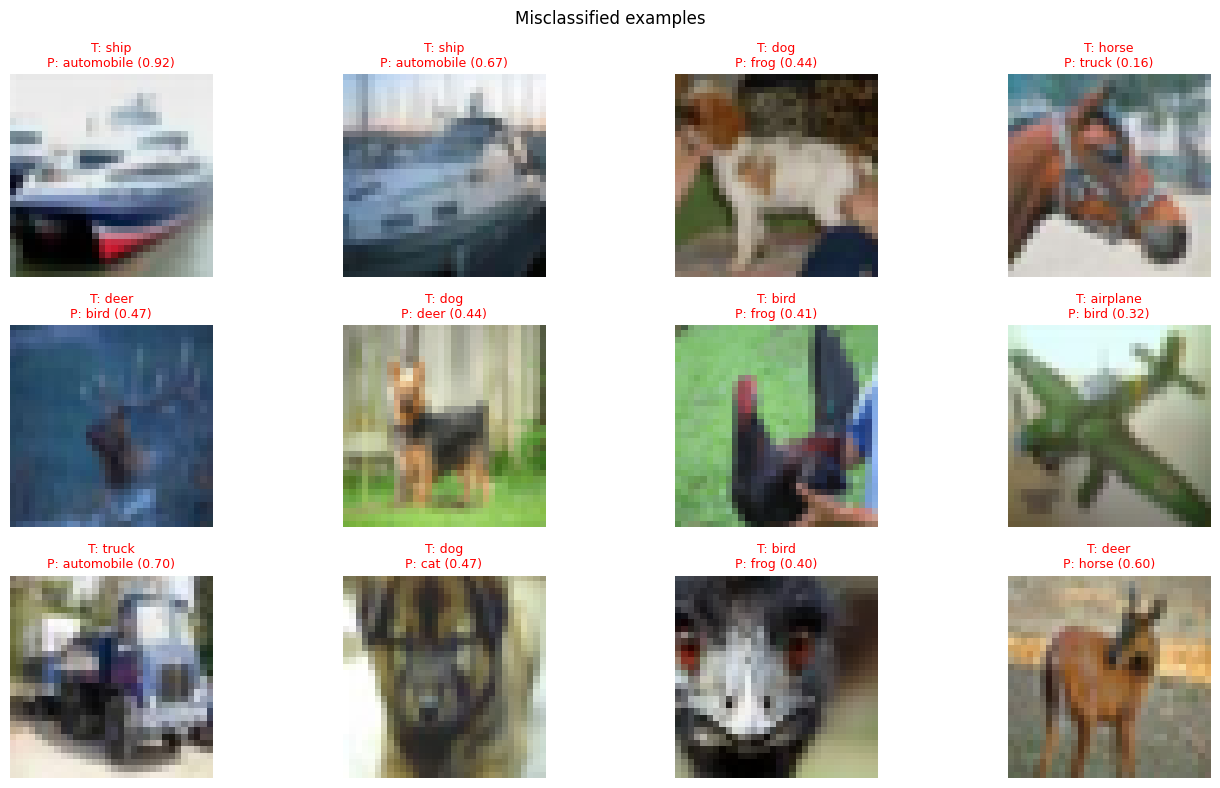

In [27]:
def show_misclassifications(images, y_true, y_pred, y_prob, class_names, n=12):
    wrong = np.where(y_true != y_pred)[0]
    if len(wrong) == 0:
        print("No misclassifications found in the inspected subset.")
        return

    chosen = wrong[:min(n, len(wrong))]
    plt.figure(figsize=(14, 8))
    for i, idx in enumerate(chosen, start=1):
        plt.subplot(3, 4, i)
        plt.imshow(images[idx])
        true_label = class_names[int(y_true[idx])]
        pred_label = class_names[int(y_pred[idx])]
        confidence = float(np.max(y_prob[idx]))
        plt.title(f"T: {true_label}\nP: {pred_label} ({confidence:.2f})", color="red", fontsize=9)
        plt.axis("off")
    plt.suptitle("Misclassified examples")
    plt.tight_layout()
    plt.show()

if TRAINED_RESULT is not None:
    show_misclassifications(X_eval, y_eval, pred_eval, prob_eval, class_names)


## 14. Visualizing What Early CNN Layers See

One way to make CNNs more intuitive is to inspect the **feature maps** produced by the first convolution block.

These feature maps are not “human concepts”.
Instead, they are learned responses to patterns such as edges, contrasts, textures, or simple shapes.

This is one of the clearest ways to connect the theory of hierarchical feature extraction to actual tensors inside the model.


In [28]:
def visualize_feature_maps_keras(model, image, max_maps=8):
    # first convolutional layer
    conv_layers = [layer for layer in model.layers if isinstance(layer, layers.Conv2D)]
    if not conv_layers:
        print("No Conv2D layers found.")
        return

    first_conv = conv_layers[0]
    feature_model = keras.Model(inputs=model.input, outputs=first_conv.output)

    fmap = feature_model.predict(image[None, ...], verbose=0)[0]
    num_maps = min(max_maps, fmap.shape[-1])

    plt.figure(figsize=(2.5 * num_maps, 3))
    for i in range(num_maps):
        plt.subplot(1, num_maps, i + 1)
        plt.imshow(fmap[:, :, i], cmap="viridis")
        plt.axis("off")
        plt.title(f"Map {i}")
    plt.suptitle("First-layer feature maps (Keras)")
    plt.tight_layout()
    plt.show()

def visualize_feature_maps_torch(model, image, max_maps=8):
    conv_layer = None
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            conv_layer = module
            break

    if conv_layer is None:
        print("No Conv2d layer found.")
        return

    activations = {}

    def hook_fn(module, inp, out):
        activations["conv"] = out.detach().cpu()

    handle = conv_layer.register_forward_hook(hook_fn)

    device = next(model.parameters()).device
    x = torch.tensor(np.transpose(image[None, ...], (0, 3, 1, 2)), dtype=torch.float32).to(device)
    model.eval()
    with torch.no_grad():
        _ = model(x)

    handle.remove()

    fmap = activations["conv"][0]
    num_maps = min(max_maps, fmap.shape[0])

    plt.figure(figsize=(2.5 * num_maps, 3))
    for i in range(num_maps):
        plt.subplot(1, num_maps, i + 1)
        plt.imshow(fmap[i], cmap="viridis")
        plt.axis("off")
        plt.title(f"Map {i}")
    plt.suptitle("First-layer feature maps (PyTorch)")
    plt.tight_layout()
    plt.show()


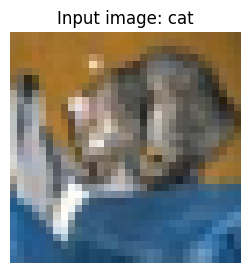

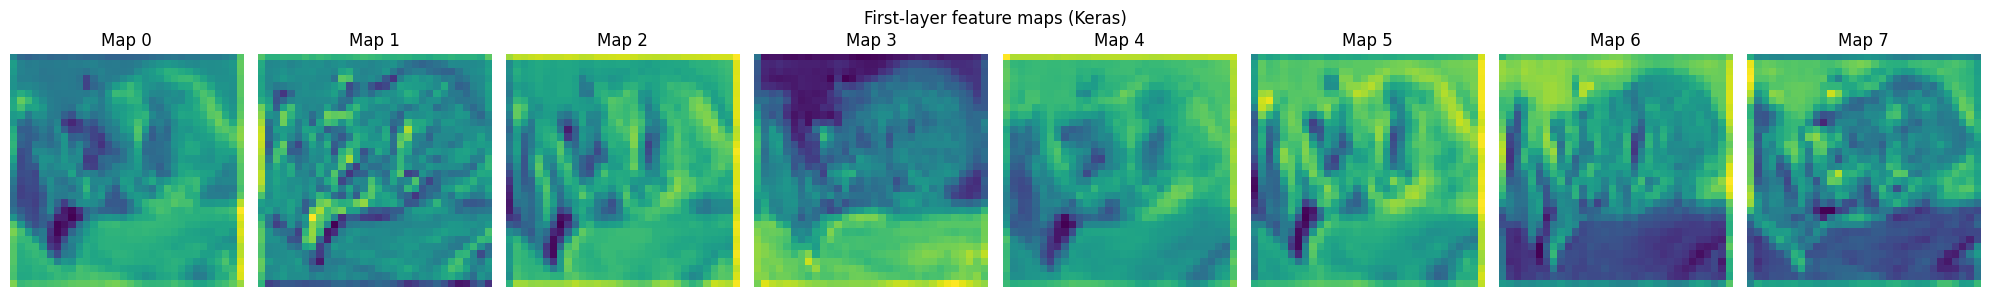

In [29]:
if TRAINED_RESULT is not None:
    sample_index = 0
    sample_image = X_eval[sample_index]
    plt.figure(figsize=(3, 3))
    plt.imshow(sample_image)
    plt.title(f"Input image: {class_names[int(y_eval[sample_index])]}")
    plt.axis("off")
    plt.show()

    if TRAINED_RESULT["framework"] == "TensorFlow/Keras":
        visualize_feature_maps_keras(TRAINED_RESULT["model"], sample_image)
    else:
        visualize_feature_maps_torch(TRAINED_RESULT["model"], sample_image)


### Keras vs. PyTorch note after feature visualization

- The **concept** is the same in both frameworks: extract and inspect intermediate activations.
- In **Keras**, intermediate outputs are often obtained by building a secondary model.
- In **PyTorch**, hooks are a common way to capture activations during a forward pass.
- This is a good example of a repeated pattern in deep learning tooling:
  - same conceptual operation,
  - different framework ergonomics.


## 15. Hyperparameter Deep Dive: Common Options, Meaning, and Practical Effects

This section is intentionally more detailed because learners often ask not just **what value to use**, but **what the choice means**.

### 15.1 Activation function

| Option | Main idea | Advantages | Risks / trade-offs |
|---|---|---|---|
| ReLU | zero for negatives, linear for positives | simple, fast, strong default | some neurons can become inactive |
| LeakyReLU | ReLU with small negative slope | reduces dead-neuron problem | slightly more complex |
| GELU | smooth, probabilistic-style gating | popular in modern deep nets | more expensive than ReLU |

### 15.2 Optimizer

| Option | Main idea | Advantages | Risks / trade-offs |
|---|---|---|---|
| SGD + momentum | classic gradient descent with velocity | simple, strong baseline, can generalize well | often needs careful learning-rate tuning |
| RMSprop | adaptive per-parameter step sizes | often stable on noisy problems | less common as a first choice than Adam |
| Adam | adaptive moments + per-parameter scaling | strong default, fast convergence | can hide bad learning-rate choices, sometimes less robust than SGD in some regimes |

### 15.3 Number of convolution blocks

| Fewer blocks | More blocks |
|---|---|
| faster training | richer hierarchical features |
| lower capacity | higher capacity |
| less memory use | more memory use |
| may underfit complex data | may overfit or train slowly |

### 15.4 Base number of filters

Examples:
- `16` -> lighter and faster
- `32` -> common default
- `64` -> more expressive, but much heavier

### 15.5 Kernel size

Common choices:
- `3x3`: most common default in many CNNs
- `5x5`: larger local context, but more computation

### 15.6 Batch normalization

Benefits:
- stabilizes activations,
- often speeds training,
- often helps deeper stacks.

Caution:
- behavior depends on batch statistics,
- very small batch sizes can make it less stable.

### 15.7 Dropout

Common choices:
- `0.0` -> no dropout
- `0.2` to `0.3` -> light regularization
- `0.5` -> strong regularization

Effect:
- can help validation accuracy if overfitting is present,
- can hurt learning if the model is already small or data-limited.

### 15.8 Batch size

Common choices:
- `32`: common default, noisier but often effective
- `64`: often a good balance
- `128`: faster on good hardware, but not always best for generalization

### 15.9 Learning rate

This is one of the most important hyperparameters.
Typical beginner experiments:
- `1e-4` -> safe but sometimes slow
- `1e-3` -> common default for Adam
- `1e-2` -> can be too large, but sometimes useful with SGD

Further study:
- Optimization overview: https://www.ruder.io/optimizing-gradient-descent/
- Keras optimizers: https://keras.io/api/optimizers/
- PyTorch optimizers: https://docs.pytorch.org/docs/stable/optim.html


## 16. Compare a Few Options Empirically

The next cells run **small comparison experiments**.
To keep runtime reasonable, these experiments use a smaller subset and fewer epochs than your main training run.

We compare:

1. activation functions,
2. optimizers,
3. network depth.

> Recommendation:
> Keep these comparison runs small and fast.
> Their purpose is to show **directional differences**, not to produce a perfect final model.


In [30]:
def make_quick_config(base_config=None, **updates):
    cfg = get_current_config() if base_config is None else base_config
    d = asdict(cfg)
    d.update(updates)
    # Keep quick comparisons lightweight
    if d.get("train_subset", 10000) == "full":
        d["train_subset"] = 5000
    d["epochs"] = min(d.get("epochs", 8), 5)
    return Config(**d)

def run_single_experiment(config: Config):
    if config.framework == "TensorFlow/Keras":
        return train_keras_model(config)
    return train_torch_model(config)

def compare_values(setting_name, values, framework=None):
    base = get_current_config()
    if framework is not None:
        base.framework = framework

    records = []
    for value in values:
        kwargs = {setting_name: value}
        cfg = make_quick_config(base, **kwargs)
        print(f"Running {setting_name}={value} | framework={cfg.framework}")
        result = run_single_experiment(cfg)
        records.append({
            "framework": cfg.framework,
            "setting": setting_name,
            "value": value,
            "test_accuracy": result["test_accuracy"],
            "test_loss": result["test_loss"],
            "total_time_sec": result["total_time"],
            "epochs_run": len(result["history"]["loss"]),
        })
    return pd.DataFrame(records)


In [31]:
# Example 1: compare activations
activation_comparison_df = compare_values(
    setting_name="activation",
    values=["relu", "leaky_relu", "gelu"],
    framework=get_current_config().framework
)

activation_comparison_df


Running activation=relu | framework=TensorFlow/Keras
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 151ms/step - accuracy: 0.2610 - loss: 2.0700 - val_accuracy: 0.1620 - val_loss: 2.6903
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 156ms/step - accuracy: 0.3674 - loss: 1.7273 - val_accuracy: 0.1090 - val_loss: 3.6017
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 153ms/step - accuracy: 0.4190 - loss: 1.5979 - val_accuracy: 0.3980 - val_loss: 1.7147
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 153ms/step - accuracy: 0.4472 - loss: 1.5011 - val_accuracy: 0.4960 - val_loss: 1.3918
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 151ms/step - accuracy: 0.4869 - loss: 1.4152 - val_accuracy: 0.4945 - val_loss: 1.3685
Running activation=leaky_relu | framework=TensorFlow/Keras
Epoch 1/5
  1/157 ━━━━━━━━━━━━━━━━━━━━ 8:00 3s/step - accuracy: 0.1719 - loss: 4.3777

E0000 00:00:1776417895.169099   51510 meta_optimizer.cc:967] remapper failed: INVALID_ARGUMENT: Mutation::Apply error: fanout 'StatefulPartitionedCall/gradient_tape/interactive_cnn_1/leaky_re_lu_2_1/LeakyRelu/LeakyReluGrad' exist for missing node 'StatefulPartitionedCall/interactive_cnn_1/conv2d_22_1/BiasAdd'.


157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 155ms/step - accuracy: 0.2931 - loss: 2.3224 - val_accuracy: 0.1210 - val_loss: 3.7738
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 154ms/step - accuracy: 0.3803 - loss: 1.8373 - val_accuracy: 0.1295 - val_loss: 3.6000
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 155ms/step - accuracy: 0.4332 - loss: 1.6629 - val_accuracy: 0.4275 - val_loss: 1.5633
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 155ms/step - accuracy: 0.4767 - loss: 1.5044 - val_accuracy: 0.5325 - val_loss: 1.3204
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 155ms/step - accuracy: 0.5112 - loss: 1.3932 - val_accuracy: 0.5395 - val_loss: 1.3565
Running activation=gelu | framework=TensorFlow/Keras
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 33s 187ms/step - accuracy: 0.2742 - loss: 2.0307 - val_accuracy: 0.1115 - val_loss: 3.2213
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 189ms/step - accuracy: 0.3720 - loss: 1.7139 - val_accuracy: 0.1175 - val_loss: 4.1058
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 189m

,framework,setting,value,test_accuracy,test_loss,total_time_sec,epochs_run
0,TensorFlow/Keras,activation,relu,0.5140,1.346668,123.603433,5
1,TensorFlow/Keras,activation,leaky_relu,0.5225,1.315153,124.362936,5
2,TensorFlow/Keras,activation,gelu,0.5020,1.346540,151.258652,5


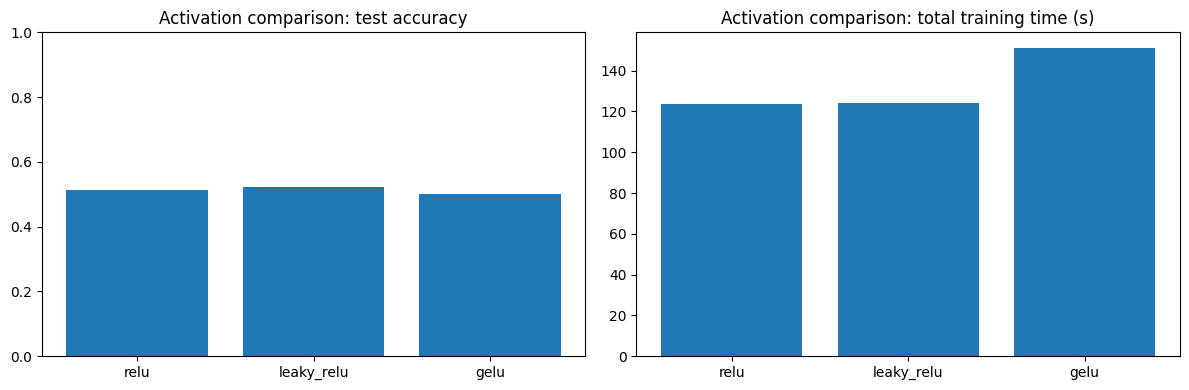

In [32]:
def plot_comparison(df, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].bar(df["value"].astype(str), df["test_accuracy"])
    axes[0].set_title(f"{title_prefix}: test accuracy")
    axes[0].set_ylim(0, 1)

    axes[1].bar(df["value"].astype(str), df["total_time_sec"])
    axes[1].set_title(f"{title_prefix}: total training time (s)")

    plt.tight_layout()
    plt.show()

plot_comparison(activation_comparison_df, "Activation comparison")


In [33]:
# Example 2: compare optimizers
optimizer_comparison_df = compare_values(
    setting_name="optimizer_name",
    values=["adam", "sgd", "rmsprop"],
    framework=get_current_config().framework
)

optimizer_comparison_df


Running optimizer_name=adam | framework=TensorFlow/Keras
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 152ms/step - accuracy: 0.2763 - loss: 2.0561 - val_accuracy: 0.1470 - val_loss: 3.0494
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 151ms/step - accuracy: 0.3812 - loss: 1.6951 - val_accuracy: 0.1130 - val_loss: 3.6412
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 152ms/step - accuracy: 0.4217 - loss: 1.5849 - val_accuracy: 0.2890 - val_loss: 2.0594
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 153ms/step - accuracy: 0.4616 - loss: 1.4884 - val_accuracy: 0.4580 - val_loss: 1.5578
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 152ms/step - accuracy: 0.4999 - loss: 1.3904 - val_accuracy: 0.4720 - val_loss: 1.4093
Running optimizer_name=sgd | framework=TensorFlow/Keras
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 150ms/step - accuracy: 0.2193 - loss: 2.3047 - val_accuracy: 0.0985 - val_loss: 3.0452
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 152ms/step - accuracy: 0.3002 - loss: 1.9113 - val_accuracy: 0.1

,framework,setting,value,test_accuracy,test_loss,total_time_sec,epochs_run
0,TensorFlow/Keras,optimizer_name,adam,0.5055,1.388894,123.220123,5
1,TensorFlow/Keras,optimizer_name,sgd,0.4190,1.566426,120.810130,5
2,TensorFlow/Keras,optimizer_name,rmsprop,0.4390,1.545729,121.755128,5


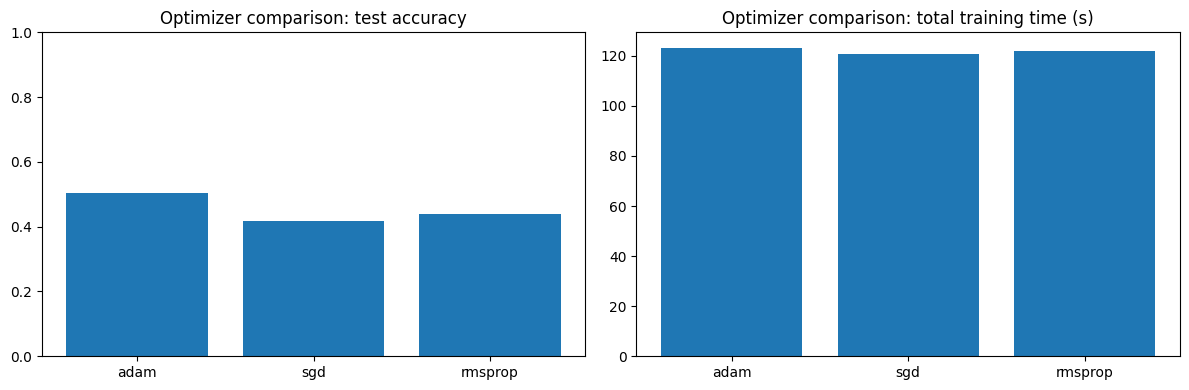

In [34]:
plot_comparison(optimizer_comparison_df, "Optimizer comparison")


In [35]:
# Example 3: compare architecture depth
depth_comparison_df = compare_values(
    setting_name="conv_blocks",
    values=[2, 3, 4],
    framework=get_current_config().framework
)

depth_comparison_df


Running conv_blocks=2 | framework=TensorFlow/Keras
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 115ms/step - accuracy: 0.2793 - loss: 2.0234 - val_accuracy: 0.1115 - val_loss: 4.5901
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 115ms/step - accuracy: 0.3873 - loss: 1.6928 - val_accuracy: 0.1520 - val_loss: 4.0650
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 116ms/step - accuracy: 0.4201 - loss: 1.5999 - val_accuracy: 0.2890 - val_loss: 2.2977
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 116ms/step - accuracy: 0.4549 - loss: 1.5102 - val_accuracy: 0.4645 - val_loss: 1.4744
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 121ms/step - accuracy: 0.4770 - loss: 1.4496 - val_accuracy: 0.5105 - val_loss: 1.3388
Running conv_blocks=3 | framework=TensorFlow/Keras
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 151ms/step - accuracy: 0.2830 - loss: 2.0357 - val_accuracy: 0.1120 - val_loss: 3.3579
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 150ms/step - accuracy: 0.3779 - loss: 1.7227 - val_accuracy: 0.1105 - val_l

,framework,setting,value,test_accuracy,test_loss,total_time_sec,epochs_run
0,TensorFlow/Keras,conv_blocks,2,0.5305,1.304885,94.621244,5
1,TensorFlow/Keras,conv_blocks,3,0.5145,1.349593,120.436280,5
2,TensorFlow/Keras,conv_blocks,4,0.4550,1.563774,148.930241,5


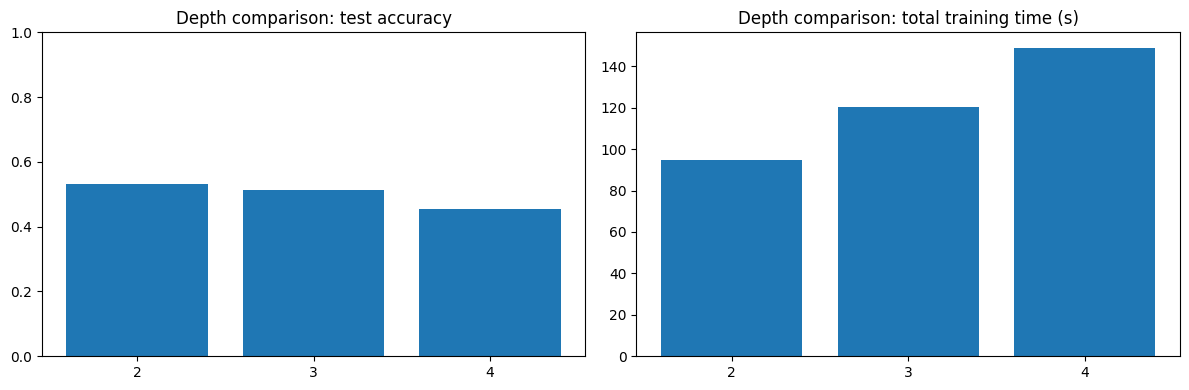

In [36]:
plot_comparison(depth_comparison_df, "Depth comparison")


### How to interpret these comparisons

Do not ask only:
> “Which number is biggest?”

Also ask:
- Which option trained faster?
- Which option was more stable?
- Did extra depth help enough to justify the time cost?
- Did an optimizer converge faster but generalize worse?
- Did the activation change only accuracy, or also runtime?

This is how practical model design works in real projects:
**performance is multi-dimensional**.


### Keras vs. PyTorch note after the comparison experiments

When you run the same comparison under both frameworks, you may see small differences due to:

- implementation details,
- data-loading behavior,
- augmentation differences,
- numerical kernels,
- and random variation.

That does **not** mean the frameworks disagree about the learning problem.
It means deep learning experiments are sensitive to many details, which is why careful logging and controlled comparisons are essential.


## 17. Upload an Image from Your Device and Run Inference

After training a model, you can upload your own image and see the model's prediction.

### Important warning about realism

CIFAR-10 is trained on tiny `32x32` images from a specific distribution.
That means:

- your own photo may be much larger,
- lighting and background may differ,
- the object may not be centered,
- and the model may still make incorrect predictions.

That is not a bug.
It is a very important lesson about **data distribution** and **generalization**.


In [37]:
def preprocess_uploaded_image_for_cifar(pil_image):
    image = pil_image.convert("RGB").resize((32, 32))
    arr = np.asarray(image).astype("float32") / 255.0
    return image, arr


In [39]:
# Interactive upload-and-predict UI
if HAS_WIDGETS:
    upload_widget = widgets.FileUpload(
        accept="image/*",
        multiple=False,
        description="Upload image"
    )
    predict_button = widgets.Button(description="Predict uploaded image")
    upload_output = widgets.Output()

    def _extract_uploaded_file_info(upload_value):
        if isinstance(upload_value, dict):
            if not upload_value:
                return None
            return next(iter(upload_value.values()))
        if isinstance(upload_value, (list, tuple)):
            if len(upload_value) == 0:
                return None
            return upload_value[0]
        return None

    def _extract_uploaded_bytes(file_info):
        if file_info is None:
            return None
        if isinstance(file_info, dict):
            content = file_info.get("content")
        else:
            content = getattr(file_info, "content", None)
        if content is None:
            return None
        if isinstance(content, memoryview):
            return content.tobytes()
        return bytes(content)

    def on_predict_clicked(_):
        with upload_output:
            clear_output()

            if TRAINED_RESULT is None:
                print("Please train a model first.")
                return

            file_info = _extract_uploaded_file_info(upload_widget.value)
            raw_bytes = _extract_uploaded_bytes(file_info)
            if raw_bytes is None:
                print("Please upload an image first.")
                return

            pil_image = Image.open(io.BytesIO(raw_bytes))

            preview_image, arr = preprocess_uploaded_image_for_cifar(pil_image)

            plt.figure(figsize=(3, 3))
            plt.imshow(preview_image)
            plt.title("Uploaded image after resize to 32x32")
            plt.axis("off")
            plt.show()

            if TRAINED_RESULT["framework"] == "TensorFlow/Keras":
                probs = TRAINED_RESULT["model"].predict(arr[None, ...], verbose=0)[0]
            else:
                device = torch.device(TRAINED_RESULT.get("device", "cpu"))
                x = torch.tensor(np.transpose(arr[None, ...], (0, 3, 1, 2)), dtype=torch.float32).to(device)
                TRAINED_RESULT["model"].eval()
                with torch.no_grad():
                    logits = TRAINED_RESULT["model"](x)
                    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

            pred_idx = int(np.argmax(probs))

            top5_idx = np.argsort(probs)[::-1][:5]
            top5_df = pd.DataFrame({
                "class": [class_names[i] for i in top5_idx],
                "probability": [float(probs[i]) for i in top5_idx],
            })

            print("Predicted class:", class_names[pred_idx])
            display(top5_df)

    import io
    predict_button.on_click(on_predict_clicked)

    display(widgets.VBox([
        widgets.HTML("<h4>Upload an image and run inference</h4>"),
        upload_widget,
        predict_button,
        upload_output
    ]))
else:
    print("ipywidgets is not available. Install it to use the upload-and-predict interface.")


## 18. Advanced Debugging and Common Challenges

More realistic models introduce more realistic problems.

### 18.1 Underfitting
Signs:
- low training accuracy,
- low validation accuracy,
- very simple decision behavior.

Possible fixes:
- increase depth,
- increase filters,
- train longer,
- use a better optimizer / learning rate.

### 18.2 Overfitting
Signs:
- training accuracy climbs,
- validation accuracy stalls or drops,
- validation loss rises.

Possible fixes:
- add dropout,
- add augmentation,
- reduce model size,
- use early stopping,
- collect more data.

### 18.3 Shape mismatch errors
Very common when moving between frameworks.

Check carefully:
- TensorFlow expects `(H, W, C)` inside each image and `(B, H, W, C)` in a batch.
- PyTorch expects `(C, H, W)` and `(B, C, H, W)`.

### 18.4 Runtime or memory issues
Common causes:
- too many filters,
- too many blocks,
- too large batch size,
- training on CPU with a heavy model.

Try:
- smaller subset,
- smaller batch size,
- fewer filters,
- fewer conv blocks.

### 18.5 Class confusion
Some CIFAR-10 classes are visually similar:
- cat vs dog
- automobile vs truck
- airplane vs ship (in low resolution or unusual contexts)

That is why confusion matrices are useful.

Further reading:
- TensorBoard guide: https://www.tensorflow.org/tensorboard/get_started
- PyTorch profiler: https://docs.pytorch.org/tutorials/recipes/recipes/profiler_recipe.html


## 19. Ethical and Correct Use of Generative AI During Experimentation

Generative AI can be helpful when you are:

- trying to understand an error message,
- asking what a hyperparameter does,
- refactoring repetitive code,
- or requesting ideas for controlled experiments.

However, good practice requires that you:

- test any generated code,
- verify important API details with official docs,
- justify changes you make to the model,
- and document what was changed and why.

Bad practice includes:
- copying hyperparameters without understanding them,
- reporting results you did not verify,
- or presenting AI-generated architecture changes as if they were carefully validated experimental findings.

A good principle:
> Use AI as a research and learning assistant, not as an unquestioned authority.


## 20. Suggested Exercises

1. Keep everything fixed and compare **ReLU**, **LeakyReLU**, and **GELU**.
   - Which performs best?
   - Which is fastest?

2. Compare **Adam**, **SGD**, and **RMSprop** using the same architecture.
   - Which converges fastest?
   - Which gives the best validation behavior?

3. Increase the number of convolution blocks from `2` to `4`.
   - How does runtime change?
   - Does validation accuracy improve enough to justify the cost?

4. Turn **batch normalization** off and rerun training.
   - Does training become less stable?

5. Train with and without **data augmentation**.
   - What changes in validation accuracy?
   - Do sample misclassifications change?

6. Upload three of your own images and analyze the model's behavior.
   - Which kinds of images does it handle well?
   - Which kinds does it struggle with?
   - How might you improve the training data or model to make it more reliable?

7. Build a small residual block and integrate it into one version of the model.
   - Does it help, hurt, or make little difference on this scale?


## 21. Key Takeaways

- CNNs are a natural next step after basic neural networks when working with images.
- Architecture design is about **trade-offs**, not just “making the network deeper”.
- Important choices such as activation, optimizer, batch normalization, dropout, and depth affect:
  - accuracy,
  - stability,
  - runtime,
  - and generalization.
- TensorFlow/Keras and PyTorch express the same concepts with different coding styles.
- Visualization tools make abstract model behavior easier to understand.
- Running inference on your own images is a powerful way to learn about generalization limits.


## 22. Where to Go Next

Strong next topics after this notebook include:

- transfer learning with pretrained CNNs,
- better data augmentation strategies,
- learning-rate schedules,
- custom training loops in more detail,
- experiment tracking with TensorBoard or Weights & Biases,
- mixed precision,
- and model deployment.

Suggested next reading:
- TensorFlow tutorials: https://www.tensorflow.org/tutorials
- Keras guides: https://keras.io/guides/
- PyTorch tutorials: https://docs.pytorch.org/tutorials/
- TorchVision model zoo: https://docs.pytorch.org/vision/stable/models.html
- Keras Applications: https://keras.io/api/applications/
